Model loaded from: /home/ji/NBA_Project/src/models/model_logistic_25_02_2025.pkl
Evaluation Metrics:
-------------------
Accuracy: 0.6126
AUC: 0.6438

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.77      0.69      7670
           1       0.58      0.41      0.48      5958

    accuracy                           0.61     13628
   macro avg       0.60      0.59      0.59     13628
weighted avg       0.61      0.61      0.60     13628

Confusion Matrix:
[[5906 1764]
 [3515 2443]]


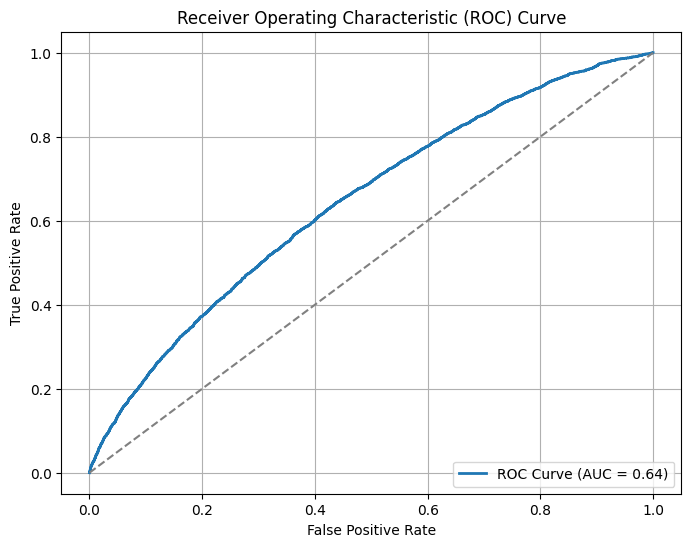

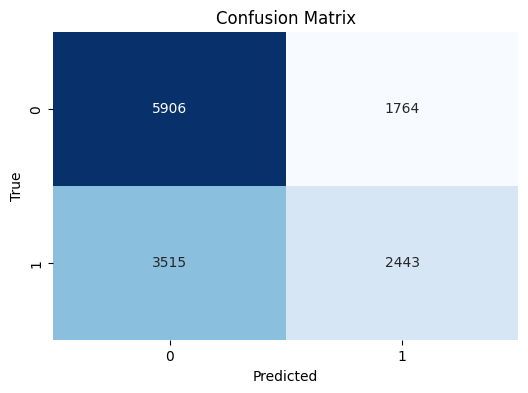

In [1]:
import pandas as pd
import joblib
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# -----------------------------
# 1. Load the Trained Model
# -----------------------------
# Define the path to your saved model file.
# Update the date if necessary, or hard-code the filename.
today_str = datetime.today().strftime("%d_%m_%Y")
model_filename = "/home/ji/NBA_Project/src/models/model_logistic_25_02_2025.pkl"

# Check if the model file exists; if not, you can specify an existing filename.
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")

model = joblib.load(model_filename)
print(f"Model loaded from: {model_filename}")

# -----------------------------
# 2. Load Evaluation Data
# -----------------------------
# Here, we assume you want to use the same cleaned data file for evaluation.
# You can also load a dedicated test file if available.
data_filename = f"/home/ji/NBA_Project/data/data_cleaned_{today_str}.csv"
df = pd.read_csv(data_filename)

# Define the list of feature columns used during training.
columns = [
    "PTS_LAST5_away",
    "FGM_LAST5_away",
    "FGA_LAST5_away",
    "FG_PCT_LAST5_away",
    "FG3M_LAST5_away",
    "FG3A_LAST5_away",
    "FG3_PCT_LAST5_away",
    "FTM_LAST5_away",
    "FTA_LAST5_away",
    "FT_PCT_LAST5_away",
    "OREB_LAST5_away",
    "DREB_LAST5_away",
    "REB_LAST5_away",
    "AST_LAST5_away",
    "STL_LAST5_away",
    "BLK_LAST5_away",
    "TOV_LAST5_away",
    "PF_LAST5_away",
    "PLUS_MINUS_LAST5_away",
    "PTS_LAST5_home",
    "FGM_LAST5_home",
    "FGA_LAST5_home",
    "FG_PCT_LAST5_home",
    "FG3M_LAST5_home",
    "FG3A_LAST5_home",
    "FG3_PCT_LAST5_home",
    "FTM_LAST5_home",
    "FTA_LAST5_home",
    "FT_PCT_LAST5_home",
    "OREB_LAST5_home",
    "DREB_LAST5_home",
    "REB_LAST5_home",
    "AST_LAST5_home",
    "STL_LAST5_home",
    "BLK_LAST5_home",
    "TOV_LAST5_home",
    "PF_LAST5_home",
    "PLUS_MINUS_LAST5_home"
]

# Extract features and target (target: WL_away)
X_eval = df[columns]
y_eval = df['WL_away']

# Ensure the feature columns have proper numeric types
X_eval = X_eval.astype(float)

# -----------------------------
# 3. Execute the Model (Prediction)
# -----------------------------
y_pred = model.predict(X_eval)
y_prob = model.predict_proba(X_eval)[:, 1]

# -----------------------------
# 4. Evaluate the Model
# -----------------------------
accuracy = accuracy_score(y_eval, y_pred)
auc_score = roc_auc_score(y_eval, y_prob)

print("Evaluation Metrics:")
print("-------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_eval, y_pred))

cm = confusion_matrix(y_eval, y_pred)
print("Confusion Matrix:")
print(cm)

# -----------------------------
# 5. Plot ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Model loaded from: /home/ji/NBA_Project/src/models/model_logistic_01_03_2025.pkl
Evaluation Metrics:
-------------------
Accuracy: 0.5628
AUC: 0.6159

Classification Report:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72      7670
           1       0.00      0.00      0.00      5958

    accuracy                           0.56     13628
   macro avg       0.28      0.50      0.36     13628
weighted avg       0.32      0.56      0.41     13628

Confusion Matrix:
[[7670    0]
 [5958    0]]


/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_star

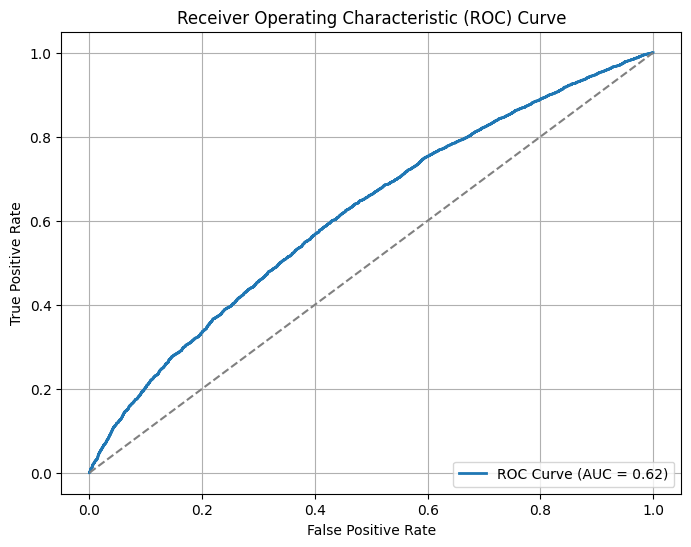

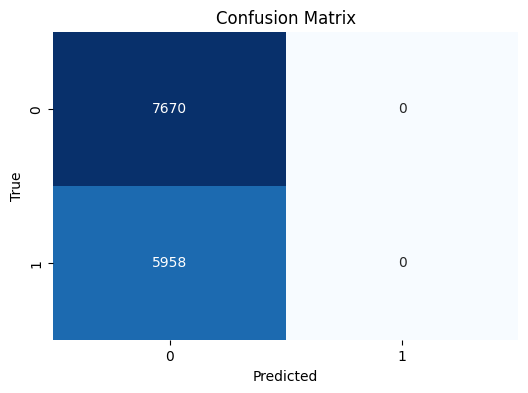

In [26]:
# -----------------------------
# 1. Load the Trained Model
# -----------------------------
# Define the path to your saved model file.
# Update the date if necessary, or hard-code the filename.
today_str = datetime.today().strftime("%d_%m_%Y")
model_filename = "/home/ji/NBA_Project/src/models/model_logistic_01_03_2025.pkl"

# Check if the model file exists; if not, you can specify an existing filename.
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")

model = joblib.load(model_filename)
print(f"Model loaded from: {model_filename}")

# -----------------------------
# 2. Load Evaluation Data
# -----------------------------
# Here, we assume you want to use the same cleaned data file for evaluation.
# You can also load a dedicated test file if available.
data_filename = f"/home/ji/NBA_Project/data/data_cleaned_{today_str}.csv"
df = pd.read_csv(data_filename)

# Define the list of feature columns used during training.
columns = ['FGM_LAST5_away', 'FGA_LAST5_away', 'FG_PCT_LAST5_away',
       'PLUS_MINUS_LAST5_away', 'FGM_LAST5_home', 'FGA_LAST5_home',
       'FG_PCT_LAST5_home', 'FG3M_LAST5_home', 'FG3A_LAST5_home',
       'PLUS_MINUS_LAST5_home']
# Extract features and target (target: WL_away)
X_eval = df[columns]
y_eval = df['WL_away']

# Ensure the feature columns have proper numeric types
X_eval = X_eval.astype(float)

# -----------------------------
# 3. Execute the Model (Prediction)
# -----------------------------
y_pred = model.predict(X_eval)
y_prob = model.predict_proba(X_eval)[:, 1]

# -----------------------------
# 4. Evaluate the Model
# -----------------------------
accuracy = accuracy_score(y_eval, y_pred)
auc_score = roc_auc_score(y_eval, y_prob)

print("Evaluation Metrics:")
print("-------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_eval, y_pred))

cm = confusion_matrix(y_eval, y_pred)
print("Confusion Matrix:")
print(cm)

# -----------------------------
# 5. Plot ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Model loaded from: /home/ji/NBA_Project/src/models/model_rf_01_03_2025.pkl


/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/ji/NBA_Project/venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Evaluation Metrics:
-------------------
Accuracy: 0.4630
AUC: 0.4675

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.32      0.40      7670
           1       0.43      0.65      0.51      5958

    accuracy                           0.46     13628
   macro avg       0.48      0.48      0.46     13628
weighted avg       0.49      0.46      0.45     13628

Confusion Matrix:
[[2425 5245]
 [2073 3885]]


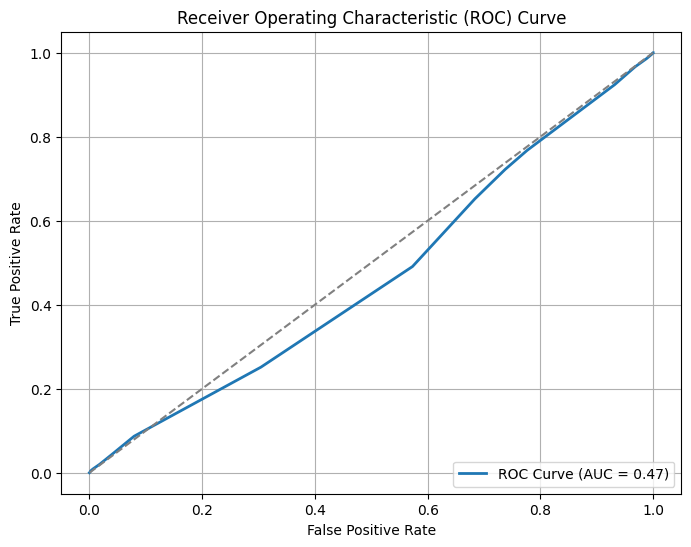

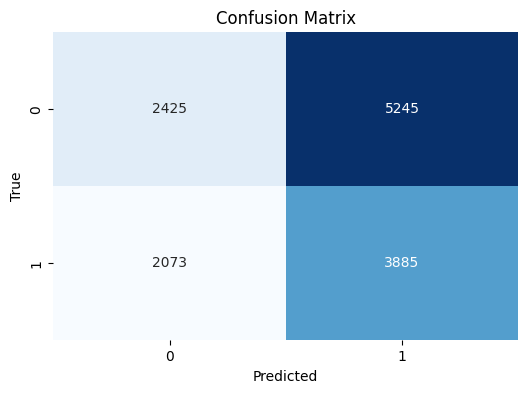

In [28]:
# -----------------------------
# 1. Load the Trained Model
# -----------------------------
# Define the path to your saved model file.
# Update the date if necessary, or hard-code the filename.
today_str = datetime.today().strftime("%d_%m_%Y")
model_filename = "/home/ji/NBA_Project/src/models/model_rf_01_03_2025.pkl"

# Check if the model file exists; if not, you can specify an existing filename.
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")

model = joblib.load(model_filename)
print(f"Model loaded from: {model_filename}")

# -----------------------------
# 2. Load Evaluation Data
# -----------------------------
# Here, we assume you want to use the same cleaned data file for evaluation.
# You can also load a dedicated test file if available.
data_filename = f"/home/ji/NBA_Project/data/data_cleaned_{today_str}.csv"
df = pd.read_csv(data_filename)

# Define the list of feature columns used during training.
columns = [
    "PTS_LAST5_away", "FGM_LAST5_away", "FGA_LAST5_away", "FG_PCT_LAST5_away",
    "FG3M_LAST5_away", "FG3A_LAST5_away", "FG3_PCT_LAST5_away", "FTM_LAST5_away",
    "FTA_LAST5_away", "FT_PCT_LAST5_away", "OREB_LAST5_away", "DREB_LAST5_away",
    "REB_LAST5_away", "AST_LAST5_away", "STL_LAST5_away", "BLK_LAST5_away",
    "TOV_LAST5_away", "PF_LAST5_away", "PLUS_MINUS_LAST5_away", "PTS_LAST5_home",
    "FGM_LAST5_home", "FGA_LAST5_home", "FG_PCT_LAST5_home", "FG3M_LAST5_home",
    "FG3A_LAST5_home", "FG3_PCT_LAST5_home", "FTM_LAST5_home", "FTA_LAST5_home",
    "FT_PCT_LAST5_home", "OREB_LAST5_home", "DREB_LAST5_home", "REB_LAST5_home",
    "AST_LAST5_home", "STL_LAST5_home", "BLK_LAST5_home", "TOV_LAST5_home",
    "PF_LAST5_home", "PLUS_MINUS_LAST5_home"
]
# Extract features and target (target: WL_away)
X_eval = df[columns]
y_eval = df['WL_away']

# Ensure the feature columns have proper numeric types
X_eval = X_eval.astype(float)

# -----------------------------
# 3. Execute the Model (Prediction)
# -----------------------------
y_pred = model.predict(X_eval)
y_prob = model.predict_proba(X_eval)[:, 1]

# -----------------------------
# 4. Evaluate the Model
# -----------------------------
accuracy = accuracy_score(y_eval, y_pred)
auc_score = roc_auc_score(y_eval, y_prob)

print("Evaluation Metrics:")
print("-------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_eval, y_pred))

cm = confusion_matrix(y_eval, y_pred)
print("Confusion Matrix:")
print(cm)

# -----------------------------
# 5. Plot ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Model loaded from: /home/ji/NBA_Project/src/models/model_xgb_01_03_2025.pkl
Evaluation Metrics:
-------------------
Accuracy: 0.5611
AUC: 0.4894

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.99      0.72      7670
           1       0.29      0.00      0.01      5958

    accuracy                           0.56     13628
   macro avg       0.43      0.50      0.36     13628
weighted avg       0.44      0.56      0.41     13628

Confusion Matrix:
[[7629   41]
 [5941   17]]


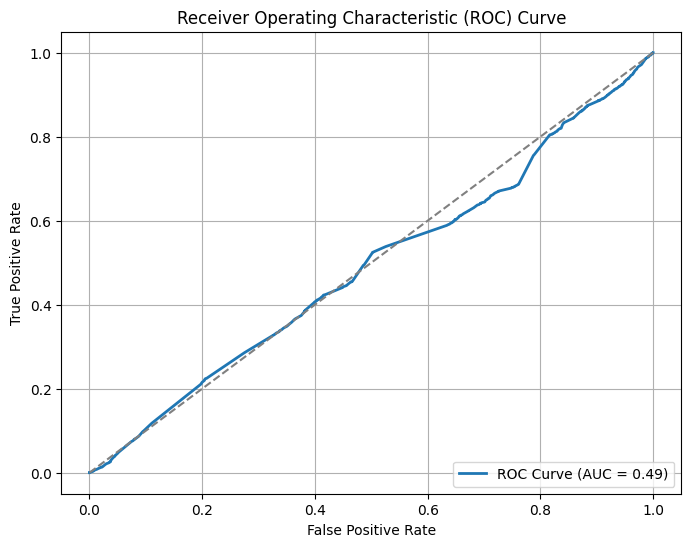

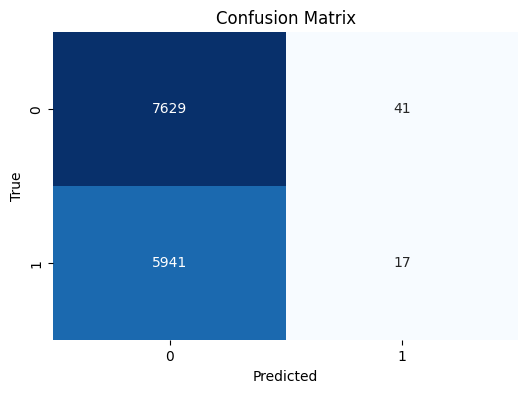

In [30]:
# -----------------------------
# 1. Load the Trained Model
# -----------------------------
# Define the path to your saved model file.
# Update the date if necessary, or hard-code the filename.
today_str = datetime.today().strftime("%d_%m_%Y")
model_filename = "/home/ji/NBA_Project/src/models/model_xgb_01_03_2025.pkl"

# Check if the model file exists; if not, you can specify an existing filename.
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")

model = joblib.load(model_filename)
print(f"Model loaded from: {model_filename}")

# -----------------------------
# 2. Load Evaluation Data
# -----------------------------
# Here, we assume you want to use the same cleaned data file for evaluation.
# You can also load a dedicated test file if available.
data_filename = f"/home/ji/NBA_Project/data/data_cleaned_{today_str}.csv"
df = pd.read_csv(data_filename)

# Define the list of feature columns used during training.
columns = [
    "PTS_LAST5_away", "FGM_LAST5_away", "FGA_LAST5_away", "FG_PCT_LAST5_away",
    "FG3M_LAST5_away", "FG3A_LAST5_away", "FG3_PCT_LAST5_away", "FTM_LAST5_away",
    "FTA_LAST5_away", "FT_PCT_LAST5_away", "OREB_LAST5_away", "DREB_LAST5_away",
    "REB_LAST5_away", "AST_LAST5_away", "STL_LAST5_away", "BLK_LAST5_away",
    "TOV_LAST5_away", "PF_LAST5_away", "PLUS_MINUS_LAST5_away", "PTS_LAST5_home",
    "FGM_LAST5_home", "FGA_LAST5_home", "FG_PCT_LAST5_home", "FG3M_LAST5_home",
    "FG3A_LAST5_home", "FG3_PCT_LAST5_home", "FTM_LAST5_home", "FTA_LAST5_home",
    "FT_PCT_LAST5_home", "OREB_LAST5_home", "DREB_LAST5_home", "REB_LAST5_home",
    "AST_LAST5_home", "STL_LAST5_home", "BLK_LAST5_home", "TOV_LAST5_home",
    "PF_LAST5_home", "PLUS_MINUS_LAST5_home"
]
# Extract features and target (target: WL_away)
X_eval = df[columns]
y_eval = df['WL_away']

# Ensure the feature columns have proper numeric types
X_eval = X_eval.astype(float)

# -----------------------------
# 3. Execute the Model (Prediction)
# -----------------------------
y_pred = model.predict(X_eval)
y_prob = model.predict_proba(X_eval)[:, 1]

# -----------------------------
# 4. Evaluate the Model
# -----------------------------
accuracy = accuracy_score(y_eval, y_pred)
auc_score = roc_auc_score(y_eval, y_prob)

print("Evaluation Metrics:")
print("-------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_eval, y_pred))

cm = confusion_matrix(y_eval, y_pred)
print("Confusion Matrix:")
print(cm)

# -----------------------------
# 5. Plot ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# 6. Plot Confusion Matrix
# -----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
